In [2]:
#import libraries
import numpy as np 
import pandas as pd
import statistics
import timeit
import matplotlib.pyplot as plt
from scipy.linalg import solve
from scipy.optimize import nnls

In [3]:
"""Creating the Microgrid class. Each day, the energy drawn from solar panels (x) and batteries (y) must satisfy two demand constraints:
3x + 2y = D1      (daytime load, kWh)
4x +  y = D2      (critical-equipment load, kWh)"""
class MicroGrid:
    def __init__(self):
        self.A = np.array([[3, 2],[4, 1]], dtype=float)
        # Computing the determinant
        self.determinant = np.linalg.det(self.A)
        # Computing the condition number
        self.condition_number = np.linalg.cond(self.A)
    
    def check_system(self):
        print("Coefficient matrix:")
        print(self.A)
        print(f"\nDeterminant: {self.determinant:.4f}")
        print(f"Condition number: {self.condition_number:.4f}")
        if np.isclose(self.determinant, 0):
            print("The system is singular and cannot be solved uniquely.")
        else:
            print("The system has a unique mathematical solution.")
    
    def solve_day(self, d1, d2):
        b = np.array([d1, d2], dtype=float)
        # Solve Ax = b
        solution = solve(self.A, b)
        solar = solution[0]
        battery = solution[1]
        return solar, battery

In [4]:
#testing
grid = MicroGrid()
grid.check_system()

Coefficient matrix:
[[3. 2.]
 [4. 1.]]

Determinant: -5.0000
Condition number: 5.8284
The system has a unique mathematical solution.


In [5]:
# interactive input() with robust validation (reject nonnumeric, negative and empty values, and re-prompt)
def get_positive_demand(prompt):
    while True:
        value = input(prompt).strip()
        if value == "":
            print("Please enter a number.")
            continue
        try:
            value = float(value)
        except ValueError:
            print("Please enter a number.")
            continue

        if value < 0:
            print("Please enter a positive number ")
            continue
        return value

In [6]:
#an interactive function
def interactive_day(grid):
    d1 = get_positive_demand("Please enter the daytime load D1 (kWh): ")
    d2 = get_positive_demand("Please enter the critical-equipment load D2 (kWh): ")
    solar, battery = grid.solve_day(d1, d2)
    print("\nResults")
    print(f"Solar usage: {solar:.2f} kWh")
    print(f"Battery usage: {battery:.2f} kWh")
    if solar < 0 or battery < 0:
        print("This  combination is physically infeasible.")
    else:
        print("The solution is physically feasible.")

In [7]:
"""loading 30 days of demand from a CSV file. Generate the CSV yourself with a seeded random 
generator: realistic values with a weekly pattern and some noise"""
rng = np.random.default_rng(42)
days = np.arange(1, 31)
d1_values = []
d2_values = []
for day in days:
    # Monday = 0,...Sunday = 6
    weekday = (day - 1) % 7
    # Weekly demand pattern
    if weekday < 5:
        weekly_effect = 5
    else:
        weekly_effect = -5
    
    d1 = 100 + weekly_effect + rng.normal(0, 8)
    d2 = 120 + weekly_effect + rng.normal(0, 10)

    d1_values.append(d1)
    d2_values.append(d2)

df = pd.DataFrame({"Day": days,"D1": d1_values,"D2": d2_values})
df.to_csv("microgrid_30_days.csv", index=False)
df.head()


,Day,D1,D2
0,1,107.437737,114.600159
1,2,111.003610,134.405647
2,3,89.391718,111.978205
3,4,106.022723,121.837574
4,5,104.865591,116.469561


In [8]:
data = pd.read_csv("microgrid_30_days.csv")

print(data.head())
print("\nNumber of days:", len(data))

   Day          D1          D2
0    1  107.437737  114.600159
1    2  111.003610  134.405647
2    3   89.391718  111.978205
3    4  106.022723  121.837574
4    5  104.865591  116.469561

Number of days: 30


In [9]:
"""Solve all 30 days with scipy.linalg.solve, first in a Python loop and then in a single 
vectorised call (pass a 2×30 right-hand side). Time both approaches with timeit and 
comment on the difference."""
def solve_with_loop(grid, data):
    results = []
    for _, row in data.iterrows():
        d1 = row["D1"]
        d2 = row["D2"]
        solution = solve(grid.A,np.array([d1, d2]))
        results.append(solution)

    return np.array(results)
loop_results = solve_with_loop(grid, data)
print(loop_results[:5])
results = data.copy()
results["Solar"] = loop_results[:, 0]
results["Battery"] = loop_results[:, 1]
results.head()

[[24.35251625 17.19009395]
 [31.56153695  8.15949935]
 [26.91293827  4.32645183]
 [27.53048499 11.71563413]
 [25.61470614 14.01073616]]


,Day,D1,D2,Solar,Battery
0,1,107.437737,114.600159,24.352516,17.190094
1,2,111.003610,134.405647,31.561537,8.159499
2,3,89.391718,111.978205,26.912938,4.326452
3,4,106.022723,121.837574,27.530485,11.715634
4,5,104.865591,116.469561,25.614706,14.010736


In [10]:
#vectorised bit
B = np.vstack([data["D1"].to_numpy(),data["D2"].to_numpy()])
print(B.shape)
vectorised_results = solve(grid.A, B)
print(vectorised_results.shape)
results["Solar_vectorised"] = vectorised_results[0]
results["Battery_vectorised"] = vectorised_results[1]

print(results.head())

(2, 30)
(2, 30)
   Day          D1          D2      Solar    Battery  Solar_vectorised  \
0    1  107.437737  114.600159  24.352516  17.190094         24.352516   
1    2  111.003610  134.405647  31.561537   8.159499         31.561537   
2    3   89.391718  111.978205  26.912938   4.326452         26.912938   
3    4  106.022723  121.837574  27.530485  11.715634         27.530485   
4    5  104.865591  116.469561  25.614706  14.010736         25.614706   

   Battery_vectorised  
0           17.190094  
1            8.159499  
2            4.326452  
3           11.715634  
4           14.010736  


In [11]:
#time the loop and vectorised approaches
loop_time = timeit.timeit(lambda: solve_with_loop(grid, data),number=1000)
print(f"Loop time: {loop_time:.6f} seconds")
def solve_vectorised(grid, data):
    B = np.vstack([data["D1"].to_numpy(),data["D2"].to_numpy()])
    return solve(grid.A, B)
vectorised_time = timeit.timeit(lambda: solve_vectorised(grid, data),number=1000)
print(f"Vectorised time: {vectorised_time:.6f} seconds")

Loop time: 2.676315 seconds
Vectorised time: 0.153595 seconds


In [12]:
"""Detect and flag physically infeasible days (negative x or y). Propose and 
implement a sensible handling strategy, for example clipping plus a report, or 
switching to a non-negative least-squares solver (scipy.optimize.nnls)."""
results["Infeasible"] = ((results["Solar"] < 0) |(results["Battery"] < 0))
print(results[results["Infeasible"]])
print("Number of infeasible days:",results["Infeasible"].sum())

    Day          D1          D2      Solar   Battery  Solar_vectorised  \
19   20   88.404150  121.505928  30.921541 -2.180237         30.921541   
26   27   83.342753  111.803288  28.052764 -0.407770         28.052764   
28   29  102.798862  139.949413  35.419993 -1.730558         35.419993   
29   30   98.073351  134.682784  34.258443 -2.350989         34.258443   

    Battery_vectorised  Infeasible  
19           -2.180237        True  
26           -0.407770        True  
28           -1.730558        True  
29           -2.350989        True  
Number of infeasible days: 4


In [13]:
#handling infeasible days
def solve_with_nnls(grid, d1, d2):
    b = np.array([d1, d2], dtype=float)
    solution, residual = nnls(grid.A, b)
    return solution[0], solution[1]
nnls_results = []

for _, row in data.iterrows():
        solar, battery = solve_with_nnls(grid,row["D1"],row["D2"])
        nnls_results.append([solar, battery])
nnls_results = np.array(nnls_results)
results["Solar_NNLS"] = nnls_results[:, 0]
results["Battery_NNLS"] = nnls_results[:, 1]

In [14]:
#compare solutions
print(results[results["Infeasible"] ][["Day","D1","D2","Solar","Battery","Solar_NNLS","Battery_NNLS"]])
#vectorised solution
B = np.vstack([data["D1"].values,data["D2"].values])
print(B.shape)
vectorised_results = solve(grid.A, B)
print(vectorised_results.shape)
"""Final solar usage/batterry usage:Use the normal mathematical solution when feasible 
and NNLS solution when the mathematical solution is infeasible."""
results["Solar_Final"] = np.where(results["Infeasible"],results["Solar_NNLS"],results["Solar"])
results["Battery_Final"] = np.where(results["Infeasible"],results["Battery_NNLS"],results["Battery"])

    Day          D1          D2      Solar   Battery  Solar_NNLS  Battery_NNLS
19   20   88.404150  121.505928  30.921541 -2.180237   30.049446           0.0
26   27   83.342753  111.803288  28.052764 -0.407770   27.889656           0.0
28   29  102.798862  139.949413  35.419993 -1.730558   34.727770           0.0
29   30   98.073351  134.682784  34.258443 -2.350989   33.318047           0.0
(2, 30)
(2, 30)


In [15]:
#descriptive statistics
solar = results["Solar_Final"].tolist()
battery = results["Battery_Final"].tolist()
solar_mean = statistics.mean(solar)
solar_variance = statistics.variance(solar)
solar_std = statistics.stdev(solar)

battery_mean = statistics.mean(battery)
battery_variance = statistics.variance(battery)
battery_std = statistics.stdev(battery)
print("SOLAR")
print(f"Mean: {solar_mean:.2f}")
print(f"Variance: {solar_variance:.2f}")
print(f"Standard deviation: {solar_std:.2f}")

print("\nBATTERY")
print(f"Mean: {battery_mean:.2f}")
print(f"Variance: {battery_variance:.2f}")
print(f"Standard deviation: {battery_std:.2f}")

SOLAR
Mean: 28.21
Variance: 7.89
Standard deviation: 2.81

BATTERY
Mean: 9.44
Variance: 39.03
Standard deviation: 6.25


In [16]:
#Cost model: given solar at UGX 150/kWh and battery at UGX 450/kWh (illustrative), compute the daily and monthly energy cost.
SOLAR_COST = 150
BATTERY_COST = 450
results["Solar_Cost"] = (results["Solar_Final"] * SOLAR_COST)
results["Battery_Cost"] = (results["Battery_Final"] * BATTERY_COST)
results["Daily_Cost"] = (results["Solar_Cost"] +results["Battery_Cost"])
print(results[["Day","Solar_Final","Battery_Final","Daily_Cost"]])
#monthly ennergy cost
monthly_cost = results["Daily_Cost"].sum()
print( f"30-day energy cost: UGX {monthly_cost:,.2f}")
#total cost from each cost
total_solar_cost = results["Solar_Cost"].sum()
total_battery_cost = results["Battery_Cost"].sum()
print(f"Total solar cost: UGX {total_solar_cost:,.2f}")
print(f"Total battery cost: UGX {total_battery_cost:,.2f}")
print(f"Total monthly cost: UGX "f"{monthly_cost:,.2f}")

    Day  Solar_Final  Battery_Final    Daily_Cost
0     1    24.352516      17.190094  11388.419714
1     2    31.561537       8.159499   8406.005253
2     3    26.912938       4.326452   5983.844066
3     4    27.530485      11.715634   9401.608108
4     5    25.614706      14.010736  10147.037192
5     6    28.704131       7.961395   7888.247589
6     7    31.403316       0.659149   5007.114507
7     8    24.814815      17.147815  11438.738836
8     9    24.574468      17.113301  11387.155532
9    10    27.394776      14.921637  10823.953209
10   11    26.572062      11.902458   9341.915403
11   12    26.425816      17.751441  11952.021046
12   13    26.276790       6.371503   6808.695006
13   14    27.610082       8.214114   7837.863715
14   15    30.062912       9.056563   8584.889988
15   16    23.947704      25.145035  14907.421201
16   17    26.564497      10.604283   8756.601925
17   18    32.530322       6.168435   7655.343861
18   19    25.821690      13.311675   9863.507313


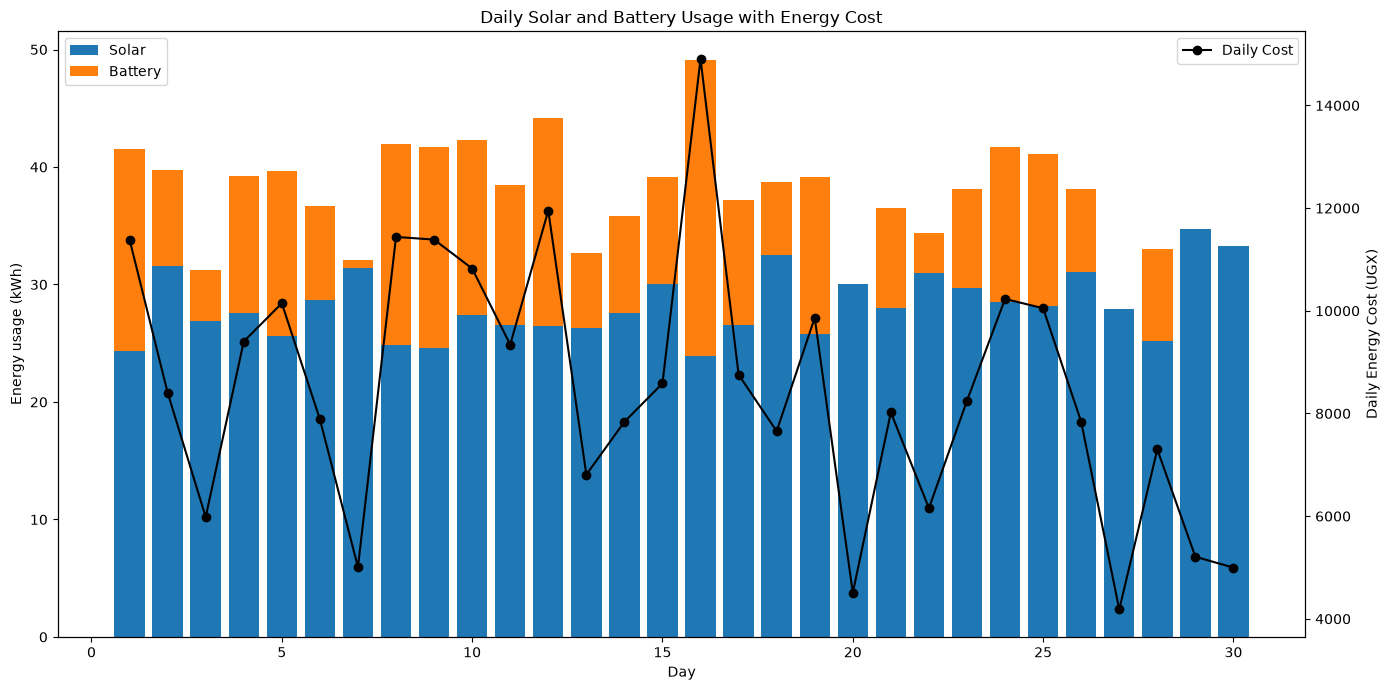

In [17]:
#Plot daily solar vs battery usage as a stacked bar chart, with a second axis showing daily cost.
fig, ax1 = plt.subplots(figsize=(14, 7))
days = results["Day"]
# Stacked energy usage
ax1.bar(days,results["Solar_Final"],label="Solar")
ax1.bar(days,results["Battery_Final"],bottom=results["Solar_Final"],label="Battery")

ax1.set_xlabel("Day")
ax1.set_ylabel("Energy usage (kWh)")
ax1.set_title("Daily Solar and Battery Usage with Energy Cost")
ax1.legend(loc="upper left")
# Second axis
ax2 = ax1.twinx()
ax2.plot(days,results["Daily_Cost"],marker="o",label="Daily Cost",color="black")
ax2.set_ylabel("Daily Energy Cost (UGX)")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()